In [ ]:
import numpy as np
from numba import njit , prange
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from joblib import Parallel, delayed
from scipy.stats import skew
from scipy.ndimage import uniform_filter1d
from scipy.signal import hilbert
import pandas as pd
from tqdm import tqdm
import progressbar 
import os, json, time, gc, io, contextlib, math
from numba import set_num_threads, get_num_threads
from operator import mod
from itertools import product
from statsmodels.tsa.stattools import adfuller
from itertools import permutations
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import TwoSlopeNorm
import glob
import imageio.v2 as imageio
from scipy.integrate import solve_ivp
from math import comb
from scipy.interpolate import interp1d
from pathlib import Path
from loguru import logger
import typer
import sys
from sklearn.mixture import GaussianMixture

PROJ_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJ_ROOT))
REPORTS_DIR = PROJ_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

import moran.methods as methods
import moran.config as config
import moran.plots as plots

g=1

2026-03-26 16:10:30.258 | INFO     | moran.config:<module>:11 - PROJ_ROOT path is: C:\Users\ah741\Desktop\fitness_waves


In [ ]:
n_individuals = 20000
b1_rate = 0.02
d1_rate = 0.03
skip = 0.01
tmax = 7.01
t_lag = 200
indices = np.arange(skip*n_individuals, tmax*n_individuals, t_lag) 
n_out = len(indices) 
trait_values = methods.generate_trait_distribution_with_hump(n_individuals, mean=-1, variance=3, hump_mass_fraction=0.2, hump_position_sigma=8.5, hump_width=2, seed=None)
# trait_values = np.zeros(n_individuals)
ex_name = f"b1_{b1_rate}_d1_{d1_rate}_N_{n_individuals}_tmax_{tmax}_skip_{skip}_lag_{t_lag}_righthump_8.5"

In [31]:
n_individuals = 20000
b1_rate = 0.04
d1_rate = 0.06
skip = 0.01
tmax = 7.01
t_lag = 200
indices = np.arange(skip*n_individuals, tmax*n_individuals, t_lag) 
n_out = len(indices) 
trait_values = methods.generate_trait_distribution_with_hump(n_individuals, mean=-1, variance=3, hump_mass_fraction=0.2, hump_position_sigma=8.5, hump_width=2, seed=None)
# trait_values = np.zeros(n_individuals)
ex_name = f"b1_{b1_rate}_d1_{d1_rate}_N_{n_individuals}_tmax_{tmax}_skip_{skip}_lag_{t_lag}_righthump_8.5"

In [2]:
n_individuals = 20000
b1_rate = 0.2
d1_rate = 0.3
skip = 0.01
tmax = 3.01
t_lag = 200
indices = np.arange(skip*n_individuals, tmax*n_individuals, t_lag) 
n_out = len(indices) 
trait_values = methods.generate_trait_distribution_with_hump(n_individuals, mean=-1, variance=3, hump_mass_fraction=0.2, hump_position_sigma=8.5, hump_width=2, seed=None)
# trait_values = np.zeros(n_individuals)
ex_name = f"b1_{b1_rate}_d1_{d1_rate}_N_{n_individuals}_tmax_{tmax}_skip_{skip}_lag_{t_lag}_righthump_8.5"

In [53]:
n_individuals = 20000
b1_rate = 0.4
d1_rate = 0.6
skip = 0.01
tmax = 2.01
t_lag = 200
indices = np.arange(skip*n_individuals, tmax*n_individuals, t_lag) 
n_out = len(indices) 
trait_values = methods.generate_trait_distribution_with_hump(n_individuals, mean=-1, variance=3, hump_mass_fraction=0.2, hump_position_sigma=8.5, hump_width=2, seed=None)
# trait_values = np.zeros(n_individuals)
ex_name = f"b1_{b1_rate}_d1_{d1_rate}_N_{n_individuals}_tmax_{tmax}_skip_{skip}_lag_{t_lag}_righthump_8.5"

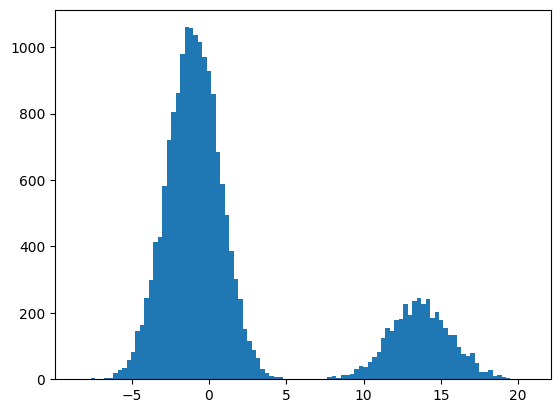

In [48]:
plt.hist(trait_values, bins=101)
plt.show()

In [96]:
# np.savez(os.path.join(FIGURES_DIR, ex_name, "data.npz"), All_tv=All_tv, Main_3D=Main_3D, Clipp=Clipp, Moments=Moments, Moments_right_tail=Moments_right_tail, Moments_left_tail=Moments_left_tail, Hist_counts=Hist_counts, Hist_edges=Hist_edges)

X = np.load(os.path.join(FIGURES_DIR, ex_name, "data.npz"))
All_tv = X["All_tv"]; Main_3D = X["Main_3D"]; Clipp = X["Clipp"]; Moments = X["Moments"]; Moments_right_tail = X["Moments_right_tail"]; Moments_left_tail = X["Moments_left_tail"]; Hist_counts = X["Hist_counts"]; Hist_edges = X["Hist_edges"]

In [3]:
All_tv, Main_3D, Clipp, Moments, Moments_right_tail, Moments_left_tail, Hist_counts, Hist_edges = methods.Quad_Sim_V2(b1_rate, 0, d1_rate, 0, tmax, indices, trait_values, nbins=128)
skwl = Main_3D[1, :]
stdl = Main_3D[2, :]
mean_trait_values = Main_3D[0, :]
ALL_b_clip_count = Clipp[0, :]
ALL_d_clip_count = Clipp[1, :]
ALL_b_clip_mass  = Clipp[2, :]
ALL_d_clip_mass  = Clipp[3, :]
ALL_wb_eff_mass  = Clipp[4, :]
ALL_wd_eff_mass  = Clipp[5, :]
ALL_mu1 = Moments[0, :]
ALL_mu2 = Moments[1, :]
ALL_mu3 = Moments[2, :]
ALL_mu4 = Moments[3, :]
ALL_moments_right_tail_1 = Moments_right_tail[0, :]
ALL_moments_right_tail_2 = Moments_right_tail[1, :]
ALL_moments_right_tail_3 = Moments_right_tail[2, :]
ALL_moments_right_tail_4 = Moments_right_tail[3, :]
ALL_moments_left_tail_1 = Moments_left_tail[0, :]
ALL_moments_left_tail_2 = Moments_left_tail[1, :]
ALL_moments_left_tail_3 = Moments_left_tail[2, :]
ALL_moments_left_tail_4 = Moments_left_tail[3, :]

varl = stdl**2
Amp_2D = np.sqrt(skwl**2 + varl)
Phase_2D = np.arctan2(skwl - np.mean(skwl), stdl - np.mean(stdl))
Freq_2D = np.diff(np.unwrap(Phase_2D))
Freq_2D = np.concatenate([Freq_2D[:1], Freq_2D])/(t_lag)*n_individuals

std_Hilbert = hilbert(stdl)
Amp_Hil_std = np.abs(std_Hilbert)
std_Hilbert = hilbert(stdl - np.mean(stdl))
Phase_Hil_std = np.angle(std_Hilbert)
Freq_Hil_std = np.diff(np.unwrap(Phase_Hil_std))
Freq_Hil_std = np.concatenate([Freq_Hil_std[:1], Freq_Hil_std])/(t_lag)*n_individuals

skw_Hilbert = hilbert(skwl)
Amp_Hil_skw = np.abs(skw_Hilbert)
skw_Hilbert = hilbert(skwl - np.mean(skwl))
Phase_Hil_skw = np.angle(skw_Hilbert)
Freq_Hil_skw = np.diff(np.unwrap(Phase_Hil_skw))
Freq_Hil_skw = np.concatenate([Freq_Hil_skw[:1], Freq_Hil_skw])/(t_lag)*n_individuals



rtspeed = np.gradient(mean_trait_values)*n_individuals/(t_lag)
Eff_slope = b1_rate + d1_rate - ALL_b_clip_count*b1_rate - ALL_d_clip_count*d1_rate
NEW_b1_rate = b1_rate * n_individuals / ALL_wb_eff_mass
NEW_d1_rate = d1_rate * n_individuals / ALL_wd_eff_mass
NEW_Eff_slope = NEW_b1_rate + NEW_d1_rate - ALL_b_clip_count*NEW_b1_rate - ALL_d_clip_count*NEW_d1_rate


Mdot = np.gradient(mean_trait_values, 1) * n_individuals / (t_lag)
Vdot = np.gradient(stdl**2, 1) * n_individuals / (t_lag)
Sdot = np.gradient(ALL_mu3, 1) * n_individuals / (t_lag) 

Nb = n_individuals*(1-ALL_b_clip_count)
Nd = n_individuals*(1-ALL_d_clip_count)
mub = (ALL_mu1*n_individuals - ALL_moments_left_tail_1)/Nb
mud = (ALL_mu1*n_individuals - ALL_moments_right_tail_1)/Nd
beff = b1_rate/(1+b1_rate*mub)
deff = d1_rate/(1-d1_rate*mud)
Vb = (ALL_mu2*n_individuals - ALL_moments_left_tail_2)/Nb - mub**2
Vd = (ALL_mu2*n_individuals - ALL_moments_right_tail_2)/Nd - mud**2
Db3 = (ALL_mu3*n_individuals - ALL_moments_left_tail_3)
Dd3 =  (ALL_mu3*n_individuals - ALL_moments_right_tail_3)
Db4 = (ALL_mu4*n_individuals - ALL_moments_left_tail_4)
Dd4 =  (ALL_mu4*n_individuals - ALL_moments_right_tail_4)
Sb = Db3/Nb - mub**3 - 3*mub*Vb
Sd = Dd3/Nd - mud**3 - 3*mud*Vd
Kb = Db4/Nb - mub**4 -6*mub**2*Vb - 4*mub*Sb
Kd = Dd4/Nd - mud**4 -6*mud**2*Vd - 4*mud*Sd

M_dot = (mub - mud)  + beff*Vb + deff*Vd
V_dot = (Vb-Vd) + (mub**2-mud**2)+ beff*(2*mub*Vb+Sb) + deff*(2*mud*Vd+Sd)+1
S_dot = ((Sb-Sd) + 3*(mub*Vb-mud*Vd) + (mub**3-mud**3) + beff*(Kb + 3*(mub**2*Vb+mub*Sb)) + deff*(Kd + 3*(mud**2*Vd+mud*Sd)) + (mub+beff*Vb)) - 3*M_dot*ALL_mu2 - 3*ALL_mu1*V_dot - 3*ALL_mu1**2*M_dot
# MVBD = np.nanmean(rtspeed / (stdl**2 * ( ( b1_rate + 2*b2_rate*mean_trait_values ) + ( d1_rate + 2*d2_rate*mean_trait_values ) )), axis=1)
if b1_rate + d1_rate == 0 : MVBD_1_ar = MVBD_2_ar = MVBD_4_ar = MVBD_5_ar = MVBD_7_ar = np.nan
else: 
    MVBD_1_ar = rtspeed / (varl * ( b1_rate + d1_rate ))
    MVBD_2_ar = rtspeed / (varl * ( Eff_slope ))
    MVBD_4_ar = rtspeed / (varl * ( NEW_b1_rate + NEW_d1_rate ))
    MVBD_5_ar = rtspeed / (varl * ( NEW_Eff_slope ))
    MVBD_7_ar = rtspeed / (M_dot)



In [4]:
plots.Plot_Moments(b1_rate, d1_rate, n_individuals, indices, Main_3D[0], Main_3D[2], Main_3D[1], FIGURES_DIR, ex_name, figsize=(25, 15), dpi=600)

In [5]:
plots.Plot_Moment_dynamics(b1_rate, d1_rate, n_individuals, indices, Mdot, Vdot, Sdot, M_dot, V_dot, S_dot, FIGURES_DIR, ex_name, figsize=(25, 15), dpi=600)

In [6]:
All_tv.shape

(300, 20000)

In [ ]:
plots.save_hist_frames_hump(All_tv, Main_3D, indices, Hist_counts, Hist_edges, t_lag, n_individuals, FIGURES_DIR, ex_name, histskip=1)


In [7]:
plots.GMM_compare_plot_frames(All_tv, indices, Hist_counts, Hist_edges, n_individuals, FIGURES_DIR, ex_name, ["bic", "bic", "aic", "aic"], [0, 1.5, 0, 1.5], histskip=1, dpi=150)

In [8]:
plots.make_video(FIGURES_DIR, ex_name, frame_duration=0.04)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1050, 1500) to (1056, 1504) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [9]:
results = methods.GMM(b1_rate, d1_rate, All_tv, Hist_edges, t_lag, sep_threshold=1.5, xic="bic")

In [11]:
Nb1 = results["nb1"]
Nb2 = results["nb2"]
Nd1 = results["nd1"]
Nd2 = results["nd2"]
Db1_1 = results["Db1_1"]
Db1_2 = results["Db1_2"]
Dd1_1 = results["Dd1_1"]
Dd1_2 = results["Dd1_2"]
Db2_1 = results["Db2_1"]
Db2_2 = results["Db2_2"]
Dd2_1 = results["Dd2_1"]
Dd2_2 = results["Dd2_2"]
Db3_1 = results["Db3_1"]
Db3_2 = results["Db3_2"]
Dd3_1 = results["Dd3_1"]
Dd3_2 = results["Dd3_2"]
hump_left = results["hump_left"]
hump_right = results["hump_right"]
hump_weight_left = results["hump_weight_left"]
hump_weight_right = results["hump_weight_right"]
hump_std_left = results["hump_std_left"]
hump_std_right = results["hump_std_right"]

dt = t_lag/n_individuals
speed_left = Mdot+np.gradient(hump_left, dt)
speed_right = Mdot+np.gradient(hump_right, dt)
mean_speed_left = np.nanmean(speed_left)
mean_speed_right = np.nanmean(speed_right)
std_speed_left = np.nanstd(speed_left)
std_speed_right = np.nanstd(speed_right)

weight_speed_left = np.gradient(hump_weight_left, dt)
weight_speed_right = np.gradient(hump_weight_right, dt)
mean_weight_speed_left = np.nanmean(weight_speed_left)
mean_weight_speed_right = np.nanmean(weight_speed_right)
mean_abs_weight_speed_left = np.nanmean(np.abs(weight_speed_left))
mean_abs_weight_speed_right = np.nanmean(np.abs(weight_speed_right))

var_left = hump_std_left**2
var_right = hump_std_right**2
var_speed_left = np.gradient(var_left, dt)
var_speed_right = np.gradient(var_right, dt)

mean_var_speed_left = np.nanmean(var_speed_left)
mean_var_speed_right = np.nanmean(var_speed_right)

wbarb = (Nb + b1_rate * mub * Nb) / (n_individuals)
wbard = (Nd - d1_rate * mud * Nd) / (n_individuals)
wbarb1 = (Nb1+b1_rate*Db1_1)/(hump_weight_left*n_individuals)
wbarb2 = (Nb2+b1_rate*Db1_2)/(hump_weight_right*n_individuals)
wbard1 = (Nd1-d1_rate*Dd1_1)/(hump_weight_left*n_individuals)
wbard2 = (Nd2-d1_rate*Dd1_2)/(hump_weight_right*n_individuals)

wbarbx1 = (Db1_1 + b1_rate*Db2_1)/(hump_weight_left*n_individuals)
wbarbx2 = (Db1_2 + b1_rate*Db2_2)/(hump_weight_right*n_individuals)
wbardx1 = (Dd1_1 - d1_rate*Dd2_1)/(hump_weight_left*n_individuals)
wbardx2 = (Dd1_2 - d1_rate*Dd2_2)/(hump_weight_right*n_individuals)

wbarbx21 = (Db2_1 + b1_rate*Db3_1)/(hump_weight_left*n_individuals)
wbarbx22 = (Db2_2 + b1_rate*Db3_2)/(hump_weight_right*n_individuals)
wbardx21 = (Dd2_1 - d1_rate*Dd3_1)/(hump_weight_left*n_individuals)
wbardx22 = (Dd2_2 - d1_rate*Dd3_2)/(hump_weight_right*n_individuals)

pred_weight_speed_right = hump_weight_right*(1-hump_weight_right)/((wbarb) * (wbard))*( wbarb2*wbard1 - wbarb1*wbard2)   
pred_weight_speed_left = - pred_weight_speed_right 

pred_mean_speed_right =  (1-hump_weight_right)/(wbarb* wbard) * (wbarb2*wbard1*(wbarbx2/wbarb2 - hump_right) - wbarb1*wbard2*(wbardx2/wbard2 - hump_right)) + hump_weight_right/(wbarb*wbard) * (wbarb2*wbard2*(wbarbx2/wbarb2-wbardx2/wbard2))
pred_mean_speed_left =  (1-hump_weight_left)/(wbarb* wbard) * (wbarb1*wbard2*(wbarbx1/wbarb1 - hump_left) - wbarb2*wbard1*(wbardx1/wbard1 - hump_left)) + hump_weight_left/(wbarb*wbard) * (wbarb1*wbard1*(wbarbx1/wbarb1-wbardx1/wbard1))

pred_var_speed_right = (1-hump_weight_right)/(wbarb* wbard) * ( wbarb2*wbard1*( (wbarbx22+g**2)/wbarb2 - var_right - 2*hump_right*wbarbx2/wbarb2 + hump_right**2 ) - wbarb1*wbard2*( (wbardx22)/wbard2 - var_right - 2*hump_right*wbardx2/wbard2 + hump_right**2 ) )   +  hump_weight_right/(wbarb*wbard) * ( (wbarbx22+g**2)/wbarb2 - wbardx22/wbard2 - 2*hump_right*(wbarbx2/wbarb2-wbardx2/wbard2) )    
pred_var_speed_left = (1-hump_weight_left)/(wbarb* wbard) * ( wbarb1*wbard2*( (wbarbx21+g**2)/wbarb1 - var_left - 2*hump_left*wbarbx1/wbarb1 + hump_left**2 ) - wbarb2*wbard1*( (wbardx21)/wbard1 - var_left - 2*hump_left*wbardx1/wbard1 + hump_left**2 ) )   +  hump_weight_left/(wbarb*wbard) * ( (wbarbx21+g**2)/wbarb1 - wbardx21/wbard1 - 2*hump_left*(wbarbx1/wbarb1-wbardx1/wbard1) )    


Simple_pred_weight_speed_right = hump_weight_right*(b1_rate+d1_rate)*hump_right
Simple_pred_weight_speed_left = hump_weight_left*(b1_rate+d1_rate)*hump_left

wbarbx = (mub*Nb + b1_rate*(ALL_mu2*n_individuals - ALL_moments_left_tail_2)) / (n_individuals)
wbardx = (mud*Nd - d1_rate*(ALL_mu2*n_individuals - ALL_moments_right_tail_2)) / (n_individuals)


# pred_mean_speed_right = (1-hump_weight_right)/(wbarb* wbard) * (wbarb2*wbard1*(wbarbx/wbarb - hump_right) - wbarb1*wbard2*(wbardx/wbard - hump_right)) + hump_weight_right/(wbarb*wbard) * (wbarb2*wbard2*(wbarbx/wbarb-wbardx/wbard))
Simple_pred_mean_speed_right = (b1_rate+d1_rate)*var_right
Simple_pred_mean_speed_left = (b1_rate+d1_rate)*var_left
# Simple_pred_mean_speed_right = (b1_rate/(1+b1_rate*hump_right)+d1_rate/(1+b1_rate*hump_right))*var_right
# Simple_pred_mean_speed_left = (b1_rate/(1+b1_rate*hump_left)+d1_rate/(1+b1_rate*hump_left))*var_left



C:\Users\ah741\AppData\Local\Temp\ipykernel_23024\2782406082.py:67: RuntimeWarning: invalid value encountered in divide
  pred_mean_speed_right =  (1-hump_weight_right)/(wbarb* wbard) * (wbarb2*wbard1*(wbarbx2/wbarb2 - hump_right) - wbarb1*wbard2*(wbardx2/wbard2 - hump_right)) + hump_weight_right/(wbarb*wbard) * (wbarb2*wbard2*(wbarbx2/wbarb2-wbardx2/wbard2))
C:\Users\ah741\AppData\Local\Temp\ipykernel_23024\2782406082.py:68: RuntimeWarning: invalid value encountered in divide
  pred_mean_speed_left =  (1-hump_weight_left)/(wbarb* wbard) * (wbarb1*wbard2*(wbarbx1/wbarb1 - hump_left) - wbarb2*wbard1*(wbardx1/wbard1 - hump_left)) + hump_weight_left/(wbarb*wbard) * (wbarb1*wbard1*(wbarbx1/wbarb1-wbardx1/wbard1))
C:\Users\ah741\AppData\Local\Temp\ipykernel_23024\2782406082.py:70: RuntimeWarning: invalid value encountered in divide
  pred_var_speed_right = (1-hump_weight_right)/(wbarb* wbard) * ( wbarb2*wbard1*( (wbarbx22+g**2)/wbarb2 - var_right - 2*hump_right*wbarbx2/wbarb2 + hump_right**

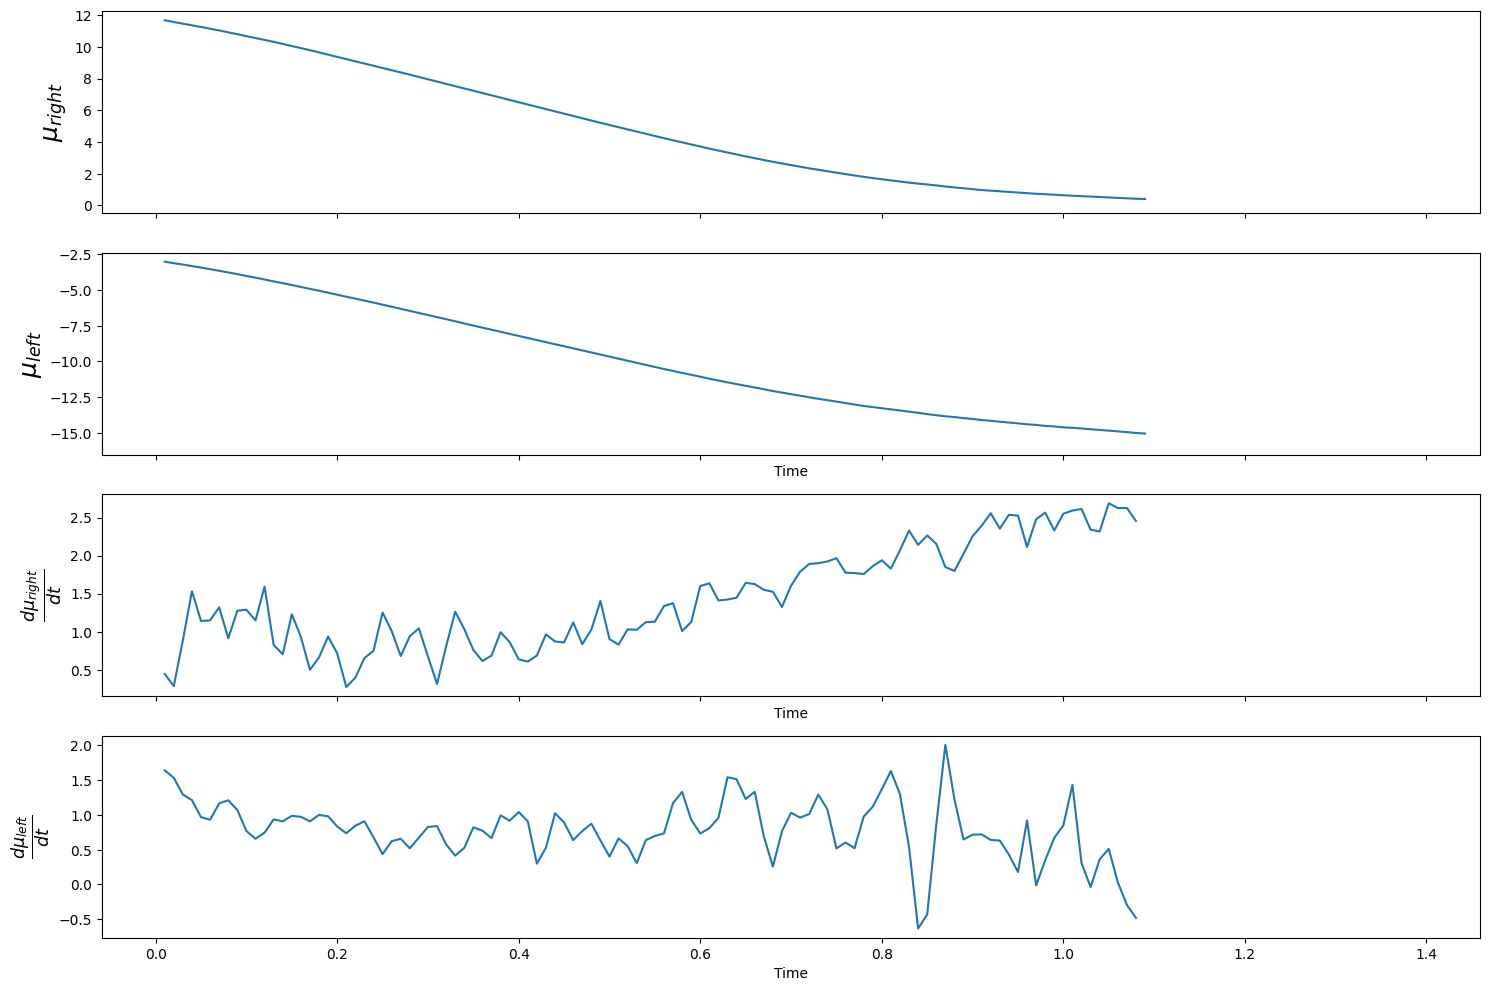

In [12]:
fig, axs = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
axs[0].plot(indices/n_individuals, hump_right)
axs[0].set_ylabel(r"$\mu_{right}$", fontsize=18) 
axs[1].plot(indices/n_individuals, hump_left)
axs[1].set_xlabel("Time")
axs[1].set_ylabel(r"$\mu_{left}$", fontsize=18)
axs[2].plot(indices/n_individuals, speed_right)
axs[2].set_xlabel("Time")
axs[2].set_ylabel(r"$\frac{d\mu_{right}}{dt}$", fontsize=18)
axs[3].plot(indices/n_individuals, speed_left)
axs[3].set_xlabel("Time")
axs[3].set_ylabel(r"$\frac{d\mu_{left}}{dt}$", fontsize=18)
plt.tight_layout()
plt.show()

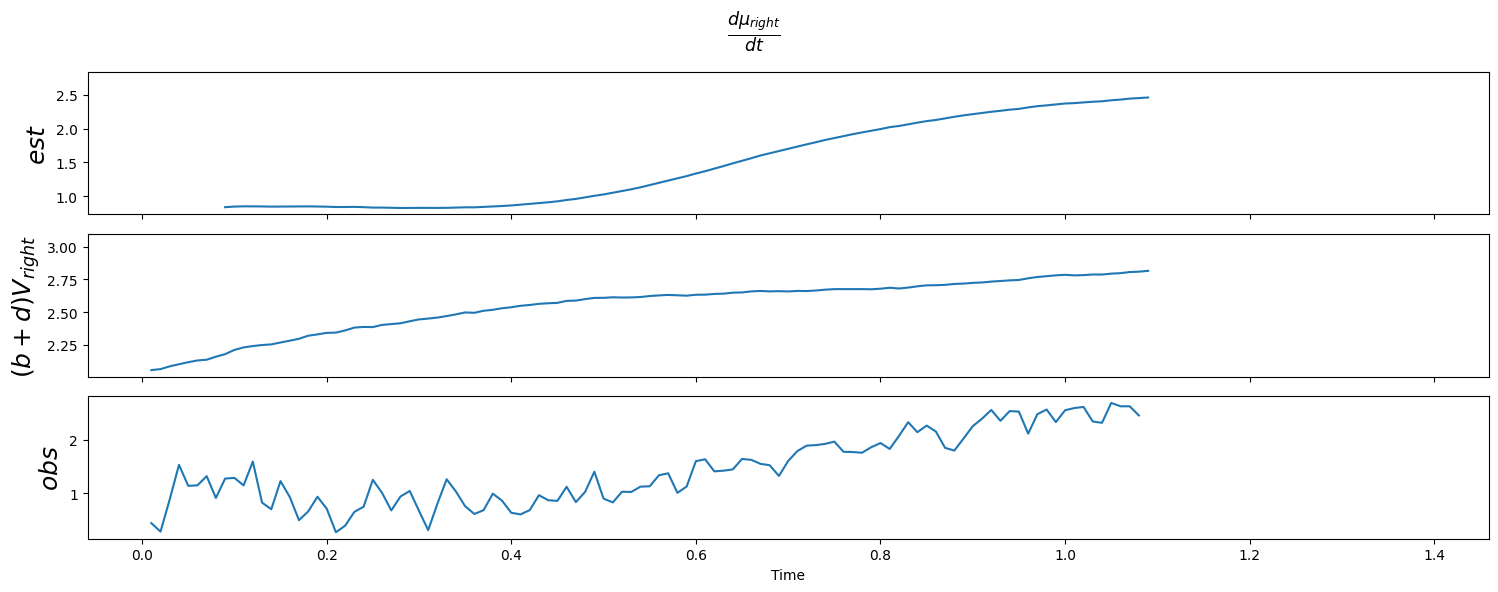

In [13]:
fig, axs = plt.subplots(3, 1, figsize=(15, 6), sharex=True)
fig.suptitle(r"$\frac{d \mu_{right}}{dt}$", fontsize=18)
axs[0].plot(indices/n_individuals, pred_mean_speed_right)
axs[0].set_ylabel(r"$est$", fontsize=18) 

axs[1].plot(indices/n_individuals, Simple_pred_mean_speed_right)
axs[1].set_ylabel(r"$(b+d)V_{right} $", fontsize=18) 

axs[2].plot(indices/n_individuals, speed_right)
axs[2].set_xlabel("Time")
axs[2].set_ylabel(r"$obs$", fontsize=18)

plt.tight_layout()
plt.show()

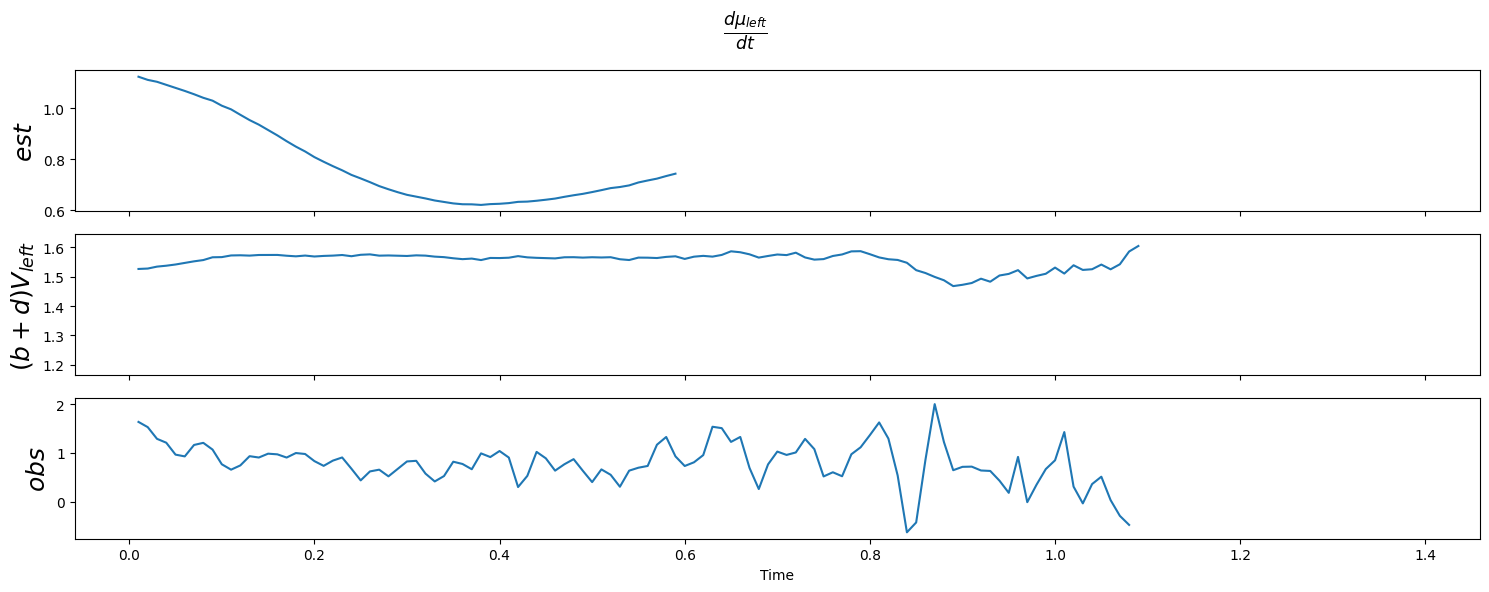

In [14]:
fig, axs = plt.subplots(3, 1, figsize=(15, 6), sharex=True)
fig.suptitle(r"$\frac{d \mu_{left}}{dt}$", fontsize=18)
axs[0].plot(indices/n_individuals, pred_mean_speed_left)
axs[0].set_ylabel(r"$est$", fontsize=18) 

axs[1].plot(indices/n_individuals, Simple_pred_mean_speed_left)
axs[1].set_ylabel(r"$(b+d)V_{left} $", fontsize=18) 

axs[2].plot(indices/n_individuals, speed_left)
axs[2].set_xlabel("Time")
axs[2].set_ylabel(r"$obs$", fontsize=18)

plt.tight_layout()
plt.show()

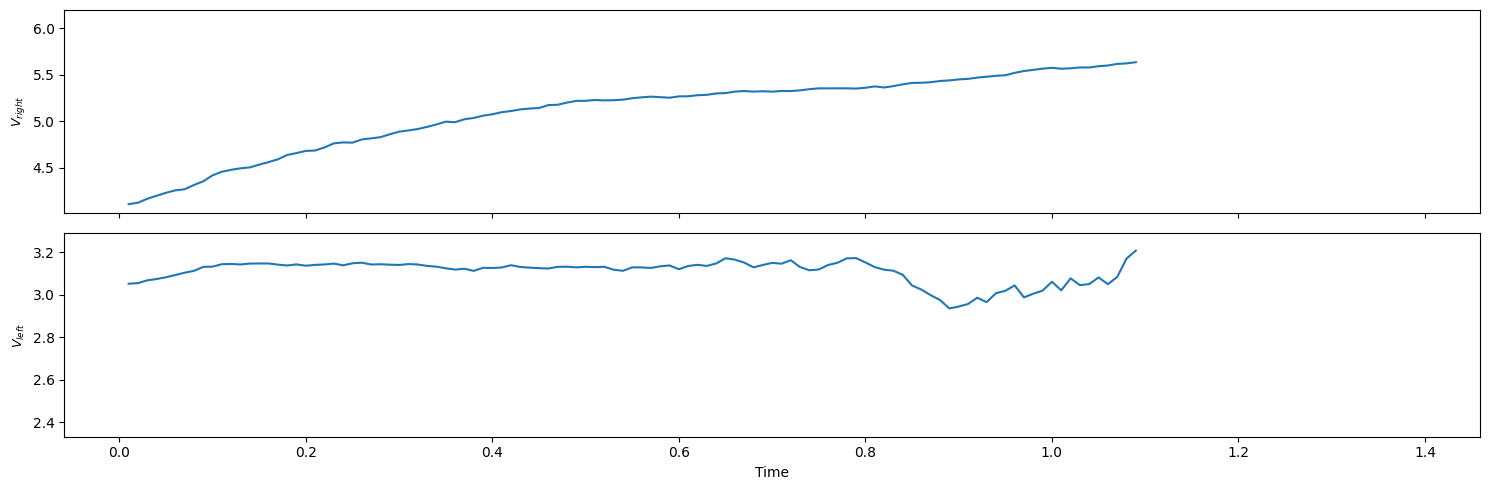

In [15]:
fig, axs = plt.subplots(2, 1, figsize=(15, 5), sharex=True)
axs[0].plot(indices/n_individuals, var_right)
axs[0].set_ylabel(r"$V_{right}$", fontsize=9) 
axs[1].plot(indices/n_individuals, var_left)
axs[1].set_xlabel("Time")
axs[1].set_ylabel(r"$V_{left}$", fontsize=9)
plt.tight_layout()
plt.show()

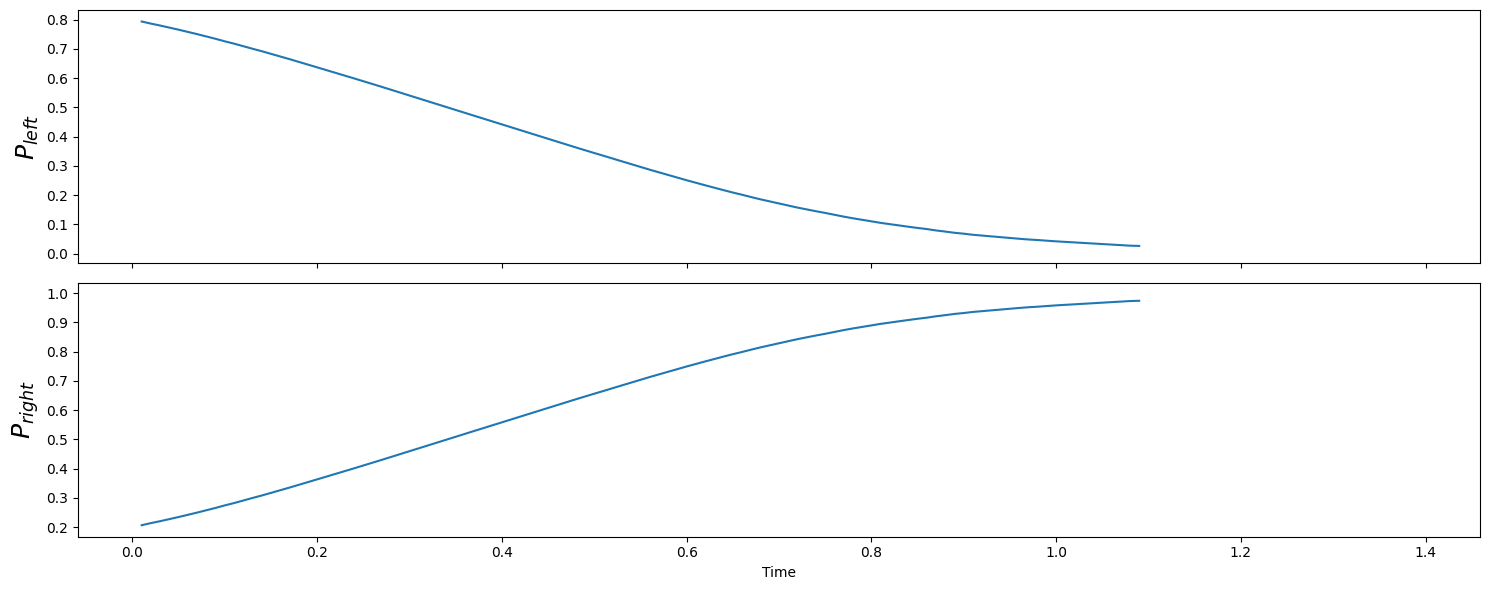

In [17]:

fig, axs = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

axs[0].plot(indices/n_individuals, hump_weight_left)
axs[0].set_ylabel(r"$P_{left}$", fontsize=18) 

axs[1].plot(indices/n_individuals, hump_weight_right)
axs[1].set_xlabel("Time")
axs[1].set_ylabel(r"$P_{right}$", fontsize=18)

plt.tight_layout()
plt.show()

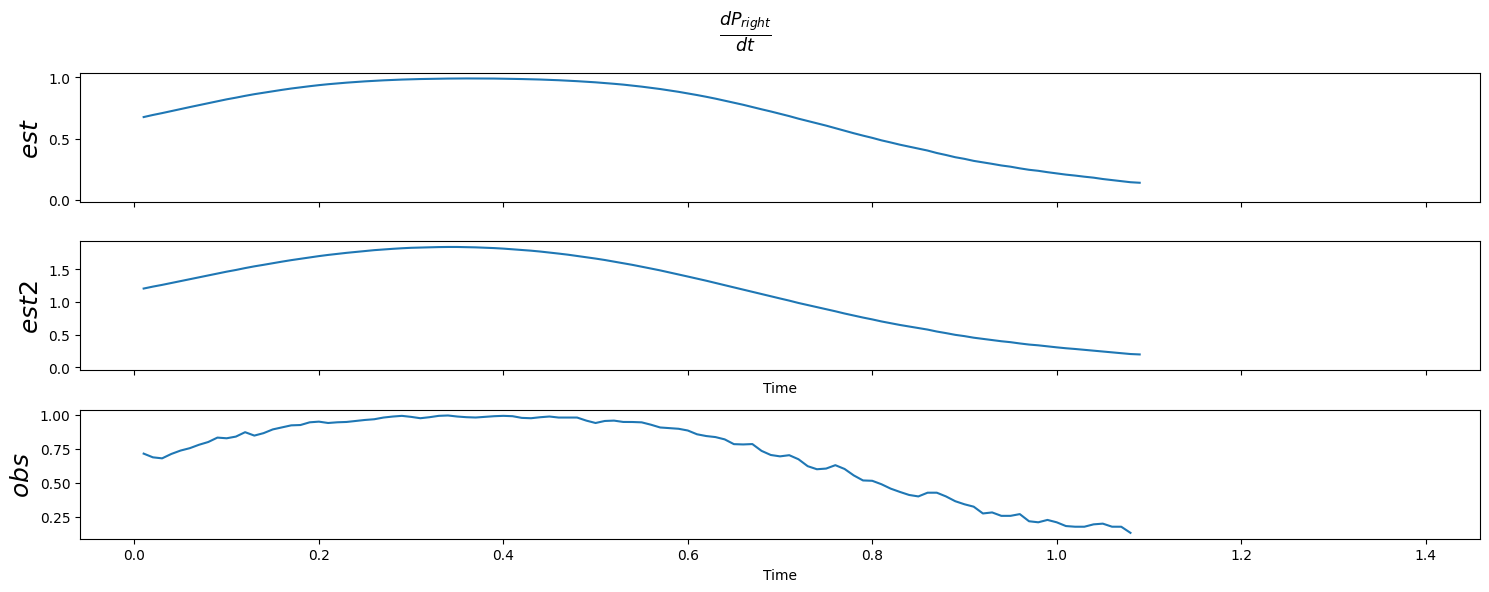

In [18]:
fig, axs = plt.subplots(3, 1, figsize=(15, 6), sharex=True)
fig.suptitle(r"$\frac{d P_{right}}{dt}$", fontsize=18)
axs[0].plot(indices/n_individuals, pred_weight_speed_right)
axs[0].set_ylabel(r"$est$", fontsize=18) 
axs[1].plot(indices/n_individuals, Simple_pred_weight_speed_right)
axs[1].set_xlabel("Time")
axs[1].set_ylabel(r"$est2$", fontsize=18)
axs[2].plot(indices/n_individuals, weight_speed_right)
axs[2].set_xlabel("Time")
axs[2].set_ylabel(r"$obs$", fontsize=18)
plt.tight_layout()
plt.show()

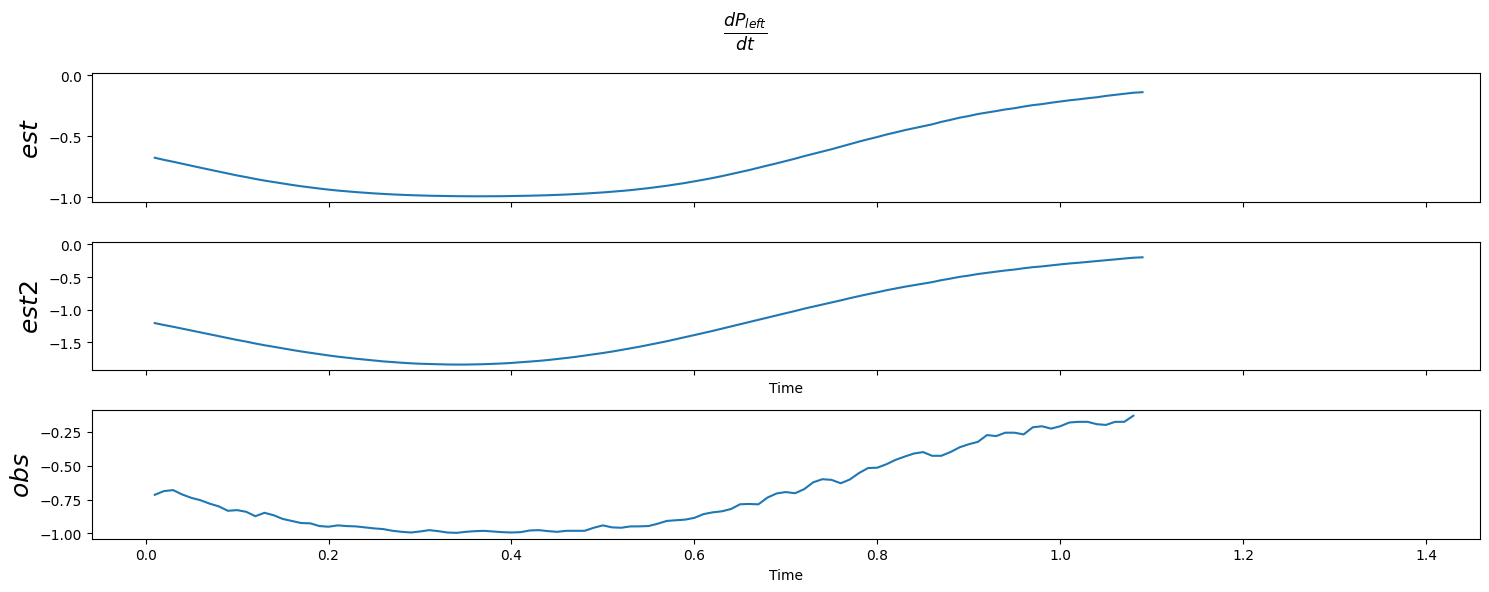

In [19]:
fig, axs = plt.subplots(3, 1, figsize=(15, 6), sharex=True)
fig.suptitle(r"$\frac{d P_{left}}{dt}$", fontsize=18)
axs[0].plot(indices/n_individuals, pred_weight_speed_left)
axs[0].set_ylabel(r"$est$", fontsize=18) 
axs[1].plot(indices/n_individuals, Simple_pred_weight_speed_left)
axs[1].set_xlabel("Time")
axs[1].set_ylabel(r"$est2$", fontsize=18)
axs[2].plot(indices/n_individuals, weight_speed_left)
axs[2].set_xlabel("Time")
axs[2].set_ylabel(r"$obs$", fontsize=18)
plt.tight_layout()
plt.show()

In [20]:
def simulate_two_morphs(    N1_0, mu1_0, V1_0,    N2_0, mu2_0, V2_0,    gamma1, gamma2,    b_plus_d,    dt=0.01,    T=10.0):
    n_steps = int(T / dt)

    # Allocate arrays
    t = np.zeros(n_steps)
    N1 = np.zeros(n_steps)
    N2 = np.zeros(n_steps)
    mu1 = np.zeros(n_steps)
    mu2 = np.zeros(n_steps)
    V1 = np.zeros(n_steps)
    V2 = np.zeros(n_steps)

    # Initial conditions
    N1[0] = N1_0
    N2[0] = N2_0
    mu1[0] = mu1_0
    mu2[0] = mu2_0
    V1[0] = V1_0
    V2[0] = V2_0
    t[0] = 0.0

    eps = 1e-12

    last_idx = 0  # track last valid index

    for i in range(n_steps - 1):

        # Stop if extinction occurs
        if N1[i] <= 1 or N2[i] <= 1:
            break

        N1_safe = max(N1[i], eps)
        N2_safe = max(N2[i], eps)

        # ---- Equations ----
        dN1 = N1[i] * b_plus_d * (mu1[i] - (N1[i]/(N1[i]+N2[i])*mu1[i]  +  N2[i]/(N1[i]+N2[i])*mu2[i] ) )
        dN2 = -dN1

        dmu1 = b_plus_d * V1[i]
        dmu2 = b_plus_d * V2[i]

        dV1 = gamma1 * (V1[i] ** 1.5) * b_plus_d + 1# - V1[i] / N1_safe
        dV2 = gamma2 * (V2[i] ** 1.5) * b_plus_d + 1# - V2[i] / N2_safe

        # ---- Euler update ----
        N1[i+1] = N1[i] + dt * dN1
        N2[i+1] = N2[i] + dt * dN2

        mu1[i+1] = mu1[i] + dt * dmu1 # - (N1[i]/(N1[i]+N2[i])*mu1[i]  +  N2[i]/(N1[i]+N2[i])*mu2[i] )
        mu2[i+1] = mu2[i] + dt * dmu2 #  - (N1[i]/(N1[i]+N2[i])*mu1[i]  +  N2[i]/(N1[i]+N2[i])*mu2[i] )

        V1[i+1] = max(V1[i] + dt * dV1, 0.0)
        V2[i+1] = max(V2[i] + dt * dV2, 0.0)

        t[i+1] = t[i] + dt

        last_idx = i + 1

    # mu1 -= (N1/(N1+N2)*mu1  +  N2/(N1+N2)*mu2 )
    # mu2 -= (N1/(N1+N2)*mu1  +  N2/(N1+N2)*mu2 )
    # ---- Trim arrays to actual size ----
    t = t[:last_idx + 1]
    N1 = N1[:last_idx + 1]
    N2 = N2[:last_idx + 1]
    mu1 = mu1[:last_idx + 1] - (N1[:last_idx + 1]/(N1[:last_idx + 1]+N2[:last_idx + 1])*mu1[:last_idx + 1]  +  N2[:last_idx + 1]/(N1[:last_idx + 1]+N2[:last_idx + 1])*mu2[:last_idx + 1] )
    mu2 = mu2[:last_idx + 1] - (N1[:last_idx + 1]/(N1[:last_idx + 1]+N2[:last_idx + 1])*mu1[:last_idx + 1]  +  N2[:last_idx + 1]/(N1[:last_idx + 1]+N2[:last_idx + 1])*mu2[:last_idx + 1] )
    V1 = V1[:last_idx + 1]
    V2 = V2[:last_idx + 1]

    return t, N1, N2, mu1, mu2, V1, V2


In [28]:
gmm2 = GaussianMixture(n_components=2)
gmm2.fit(trait_values.reshape(-1,1))
bic2 = gmm2.bic(trait_values.reshape(-1,1))
mean2_1, mean2_2 = gmm2.means_.flatten()
std2_1, std2_2 = np.sqrt(gmm2.covariances_.flatten())
weights2_1, weights2_2 = gmm2.weights_.flatten()

In [ ]:
mean2_1, mean2_2, std2_1**2, std2_2**2, weights2_1, weights2_2

In [50]:
np.var(trait_values), 0.8*3 + 0.2*3.83 + 0.8*0.2*(13.7+1)**2

(np.float64(37.740382021777876), 37.74040000000001)

In [21]:
N1_0 = int(20000*0.8)
N2_0 = int(20000*0.2)
mu1_0 = -1
mu2_0 = 13.75
V1_0 = 3
V2_0 = 4
gamma1 = 0
gamma2 = 0
b_plus_d = 1
b_min_d = -0.2 
b_plus_d = 0.1
b_min_d = -0.02 

b_plus_d = 0.5
b_min_d = -0.1

t, N1, N2, mu1, mu2, V1, V2 = simulate_two_morphs(    N1_0, mu1_0, V1_0,    N2_0, mu2_0, V2_0,    gamma1, gamma2,    b_plus_d,    dt=0.001,    T=5)

dp1dt = np.gradient(N1/(N1_0+N2_0), 0.001)
dp2dt = np.gradient(N2/(N1_0+N2_0), 0.001)
dmu1dt = np.gradient(mu1, 0.001)
dmu2dt = np.gradient(mu2, 0.001)

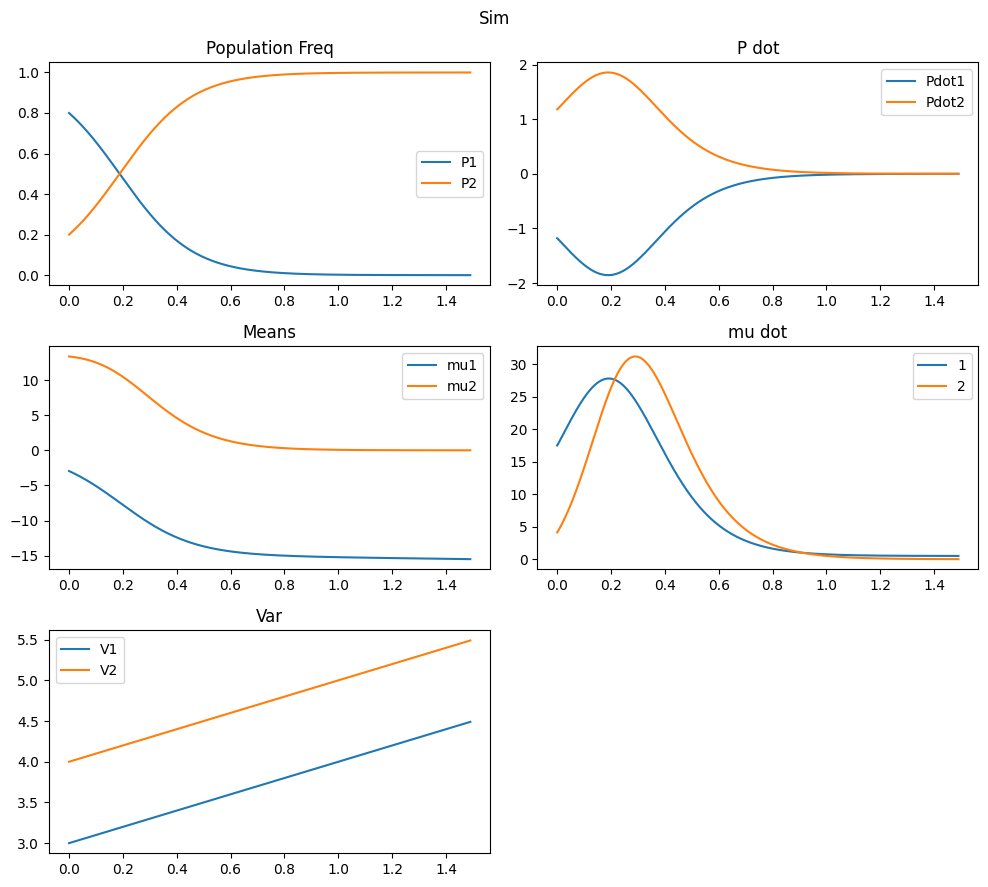

In [22]:
plt.figure(figsize=(10, 9))
plt.suptitle("Sim")

plt.subplot(3,2,1)
plt.plot(t, N1/(N1_0+N2_0), label="P1")
plt.plot(t, N2/(N1_0+N2_0), label="P2")
plt.legend()
plt.title("Population Freq")

plt.subplot(3,2,2)
plt.plot(t, dp1dt, label="Pdot1")
plt.plot(t, dp2dt, label="Pdot2")
plt.legend()
plt.title("P dot")

plt.subplot(3,2,3)
plt.plot(t, mu1, label="mu1")
plt.plot(t, mu2, label="mu2")
plt.legend()
plt.title("Means")

plt.subplot(3,2,4)
plt.plot(t, -dmu1dt, label="1")
plt.plot(t, -dmu2dt, label="2")
plt.legend()
plt.title("mu dot")

plt.subplot(3,2,5)
plt.plot(t, V1, label="V1")
plt.plot(t, V2, label="V2")
plt.legend()
plt.title("Var")

plt.tight_layout()
plt.show()

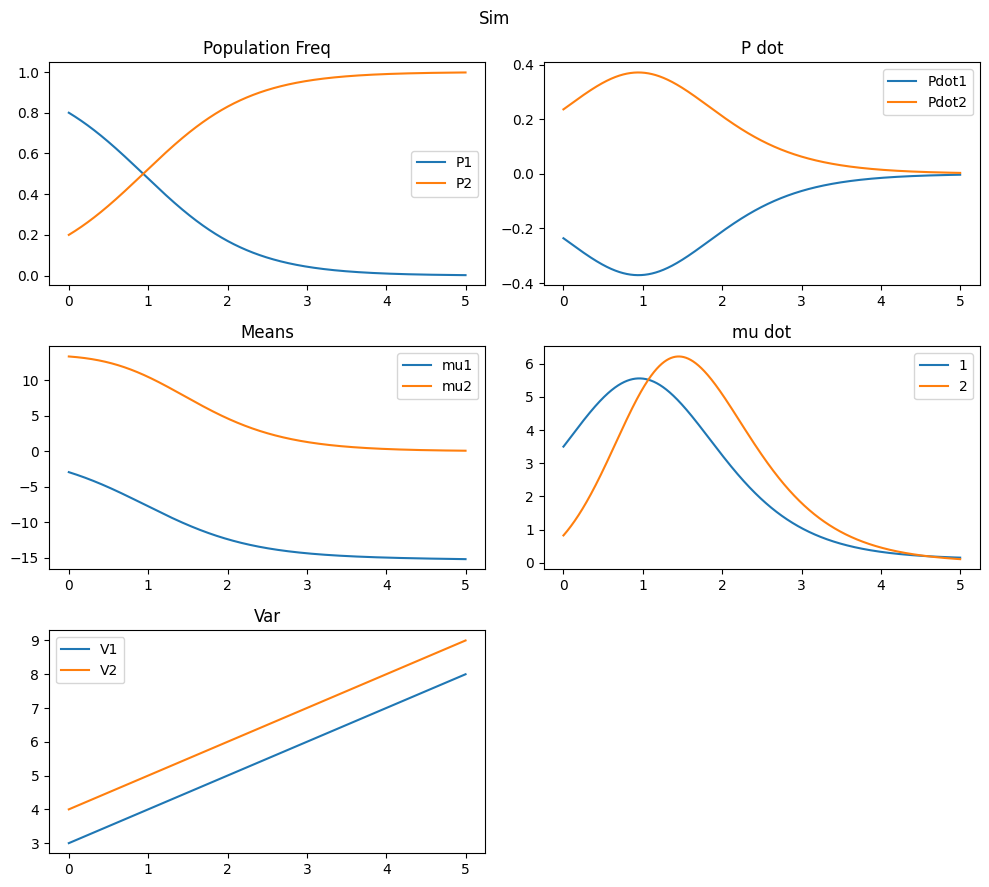

In [94]:
plt.figure(figsize=(10, 9))
plt.suptitle("Sim")

plt.subplot(3,2,1)
plt.plot(t, N1/(N1_0+N2_0), label="P1")
plt.plot(t, N2/(N1_0+N2_0), label="P2")
plt.legend()
plt.title("Population Freq")

plt.subplot(3,2,2)
plt.plot(t, dp1dt, label="Pdot1")
plt.plot(t, dp2dt, label="Pdot2")
plt.legend()
plt.title("P dot")

plt.subplot(3,2,3)
plt.plot(t, mu1, label="mu1")
plt.plot(t, mu2, label="mu2")
plt.legend()
plt.title("Means")

plt.subplot(3,2,4)
plt.plot(t, -dmu1dt, label="1")
plt.plot(t, -dmu2dt, label="2")
plt.legend()
plt.title("mu dot")

plt.subplot(3,2,5)
plt.plot(t, V1, label="V1")
plt.plot(t, V2, label="V2")
plt.legend()
plt.title("Var")

plt.tight_layout()
plt.show()

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# generate synthetic data

data1 = np.random.normal(0, 0.5, 1000)
data2 = np.random.normal(3, 1.0, 10000)

data = np.concatenate([data1, data2])
data = data.reshape(-1,1)

# fit GMM
gmm = GaussianMixture(n_components=2)
gmm.fit(data)

# parameters
means = gmm.means_.flatten()
stds = np.sqrt(gmm.covariances_.flatten())
weights = gmm.weights_

print("means:", means)
print("stds:", stds)
print("weights:", weights)

means: [1.33986862 3.22859239]
stds: [1.21390441 0.88421285]
weights: [0.26798658 0.73201342]


In [12]:
data = np.concatenate([data1, data2])
dataa = data.reshape(-1,1)

In [14]:
dataa.shape

(11000, 1)

In [59]:
gmm.covariances_.flatten()

array([0.78008565, 1.56247519])

In [60]:
gmm.means_.flatten()

array([3.21327241, 1.27065063])

In [66]:
logprob = gmm.score_samples(data)
pdf = np.exp(logprob)

In [67]:
pdf.shape

(11000,)

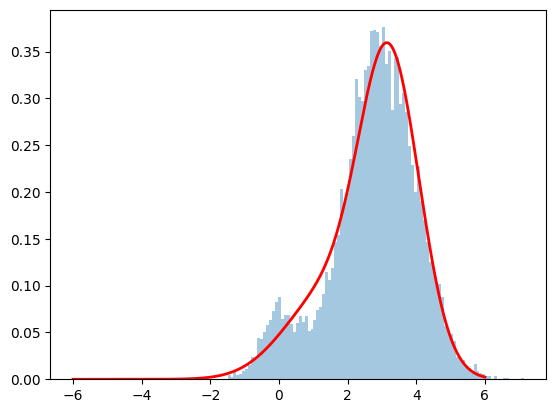

In [70]:
x = np.linspace(-6,6,1000).reshape(-1,1)

logprob = gmm.score_samples(x)
pdf = np.exp(logprob)

plt.hist(data, bins=100, density=True, alpha=0.4)

plt.plot(x, pdf, 'r', lw=2)

plt.show()

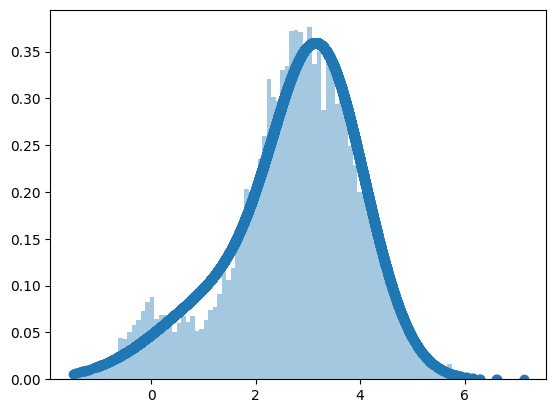

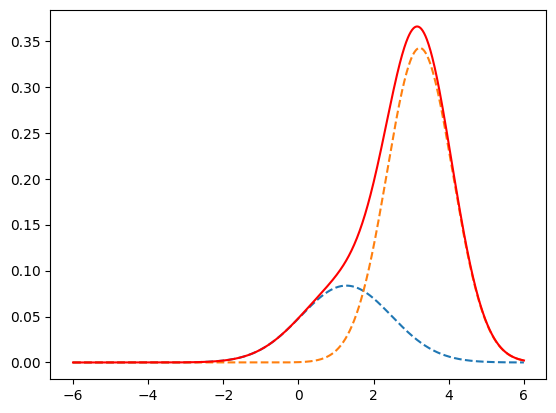

In [39]:
from scipy.stats import norm

x = np.linspace(-6,6,1000)

for i in range(2):
    plt.plot(
        x,
        weights[i]*norm.pdf(x, means[i], stds[i]),
        '--'
    )

plt.plot(x, pdf, 'r')
plt.show()

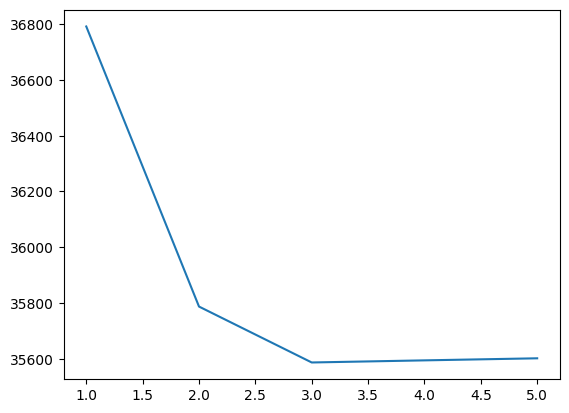

In [41]:
bics = []
for k in range(1,6):
    gmm = GaussianMixture(n_components=k)
    gmm.fit(data)
    bics.append(gmm.bic(data))

plt.plot(range(1,6), bics)
plt.show()

In [42]:
bics

[np.float64(36791.868240000586),
 np.float64(35787.063079778294),
 np.float64(35586.448600938485),
 np.float64(35594.03460414795),
 np.float64(35601.42327938343)]

In [25]:
from scipy.stats import norm

def gaussian_overlap(mu1, s1, mu2, s2):

    x = np.linspace(
        min(mu1-4*s1, mu2-4*s2),
        max(mu1+4*s1, mu2+4*s2),
        10000
    )

    p1 = norm.pdf(x, mu1, s1)
    p2 = norm.pdf(x, mu2, s2)

    overlap = np.trapezoid(np.minimum(p1, p2), x)

    return overlap

In [44]:
ovl = gaussian_overlap(means[0], stds[0], means[1], stds[1])
print("Overlap =", ovl)

Overlap = 0.3387218289425539


In [27]:
def separation_metric(mu1,s1,mu2,s2):
    return abs(mu1-mu2)/np.sqrt(s1**2+s2**2)

In [43]:
separation_metric(means[0], stds[0], means[1], stds[1])

np.float64(1.3169832170383524)

In [ ]:
# Detect hump nucleation events
hump_events = np.where((~bimodal_flag[:-1]) & (bimodal_flag[1:]))[0] + 1 

# Waiting times between hump events
if len(hump_events) > 1:
    waiting_times = np.diff(indices[hump_events])
    mean_waiting = np.mean(waiting_times)
    std_waiting = np.std(waiting_times)
else:
    mean_waiting = np.nan
    std_waiting = np.nan

# Where humps nucleate
nucleation_left = hump_left[hump_events]
nucleation_right = hump_right[hump_events]
hump_distance = hump_right[hump_events] - hump_left[hump_events]

# Statistics
mean_nucl_left = np.nanmean(nucleation_left)
mean_nucl_right = np.nanmean(nucleation_right)
std_nucl_left = np.nanstd(nucleation_left)
std_nucl_right = np.nanstd(nucleation_right)
mean_hump_distance = np.nanmean(hump_distance)

mean_nucl_left, std_nucl_left, mean_nucl_right, std_nucl_right, mean_hump_distance, mean_waiting, std_waiting